In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
file_path = r"C:\Users\sjs93\OneDrive - University of Florida\Desktop\PL_NAc_ArchT_Cre_pilot1_2_data\Opto_pilot1_2_sm_exclusions.xlsx"

df = pd.read_excel(file_path)

print(df.head())

  sex animal fam level  group laser  social agent ROI  novel ROI   \
0   m  1.1.1        cm  ArchT   off               3.8       181.0   
1   f  5.1.1        cm  ArchT   off              33.6        89.3   
2   m  1.1.1       lf   ArchT   off             111.1        60.4   
3   f  5.1.1       lf   ArchT   off             117.8        20.1   
4   f  4.2.1       lf   ArchT    on              20.3        90.4   

   whole chamber social agent   whole chamber novel   discrimintaion index  
0                          5.6                 216.7              0.958874  
1                         47.9                 120.5              0.453214  
2                        142.4                  87.6             -0.295627  
3                        147.3                  29.7             -0.708484  
4                         31.5                 161.0              0.633243  


In [11]:
print(df.columns)

Index(['sex', 'animal', 'fam level', 'group', 'laser', 'social agent ROI',
       'novel ROI ', 'whole chamber social agent ', 'whole chamber novel ',
       'discrimintaion index'],
      dtype='object')


In [30]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# rename for sanity
df = df.rename(columns={
    "discrimintaion_index": "di"
})

# make sure types are correct
df["laser"] = df["laser"].str.lower()
df["fam_level"] = df["fam_level"].str.strip()
df["group"] = df["group"].str.strip()

In [31]:
df_pivot = df.pivot_table(
    index=["animal", "sex", "fam_level", "group"],  # filters
    columns="laser",
    values="di"
).reset_index()

In [33]:
def plot_paired(ax, data, title, color):
    for _, row in data.iterrows():
        if pd.notna(row["on"]) and pd.notna(row["off"]):

            # 👇 NEW: marker by sex
            if row["sex"] == "f":
                marker = 'o'
            elif row["sex"] == "m":
                marker = 's'
            else:
                marker = 'o'

            ax.plot(
                ["ON", "OFF"],
                [row["on"], row["off"]],
                color='gray',
                alpha=0.6,
                linewidth=1.5
            )

            ax.scatter(
                ["ON", "OFF"],
                [row["on"], row["off"]],
                color=color,
                s=80,
                marker=marker   # 👈 USE IT HERE
            )

In [ ]:
# def plot_paired(ax, data, title, color):
#     for _, row in data.iterrows():
#         if pd.notna(row["on"]) and pd.notna(row["off"]):
#             ax.plot(
#                 ["ON", "OFF"],
#                 [row["on"], row["off"]],
#                 marker='o',
#                 color='black',
#                 alpha=0.7
#             )
#             ax.scatter(["ON","OFF"], [row["on"], row["off"]],
#                        color=color, s=50)

#     ax.axhline(0, linestyle='-', color='black')
#     ax.set_ylim(-1, 1)
#     ax.set_title(title, fontsize=12)
#     ax.set_ylabel("DI")

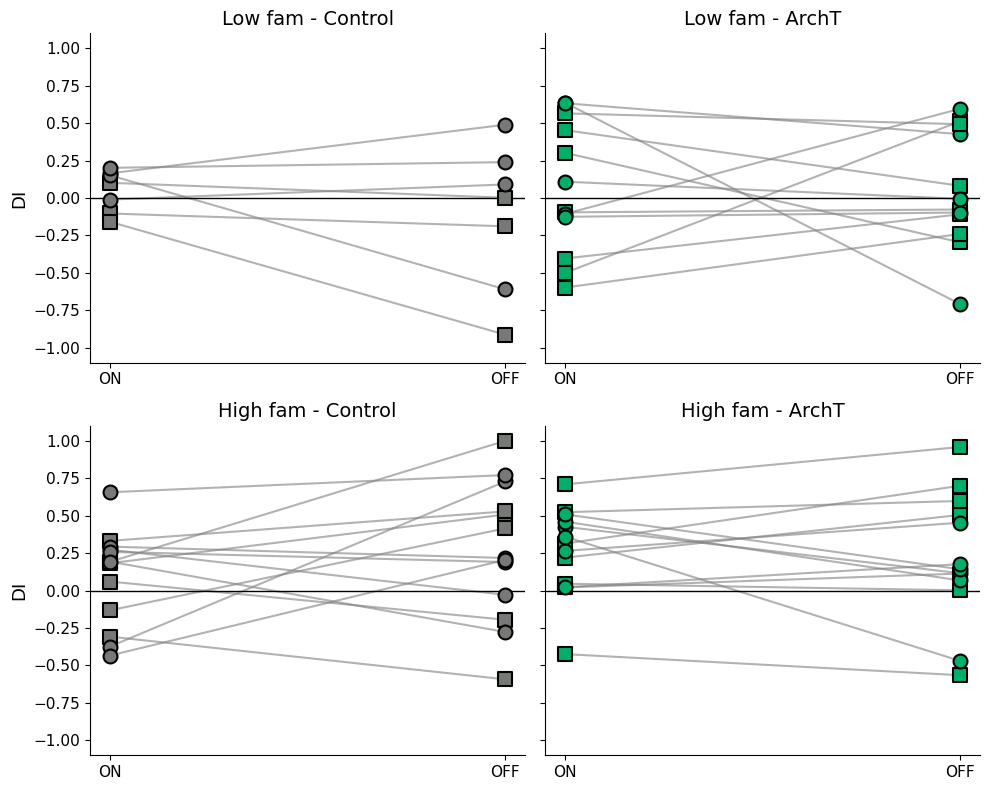

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(10,8), sharey=True)

# colors (your updated palette)
archt_color = "#02AF6A"   # green/teal
control_color = "#767975" # near black

# subsets
lf_archt = df_pivot[(df_pivot.fam_level=="lf") & (df_pivot.group=="ArchT")]
hf_archt = df_pivot[(df_pivot.fam_level=="cm") & (df_pivot.group=="ArchT")]

lf_ctrl = df_pivot[(df_pivot.fam_level=="lf") & (df_pivot.group=="control")]
hf_ctrl = df_pivot[(df_pivot.fam_level=="cm") & (df_pivot.group=="control")]

def plot_paired(ax, data, title, color):
    for _, row in data.iterrows():
        if pd.notna(row["on"]) and pd.notna(row["off"]):

            # 🔥 marker based on sex
            if row["sex"] == "f":
                marker = 'o'   # Female = circle
            elif row["sex"] == "m":
                marker = 's'   # Male = square
            else:
                marker = 'o'   # fallback

            # connecting line
            ax.plot(
                ["ON", "OFF"],
                [row["on"], row["off"]],
                color='gray',
                alpha=0.6,
                linewidth=1.5
            )

            # points with sex-specific marker
            ax.scatter(
        ["ON", "OFF"],
        [row["on"], row["off"]],
        color=color,
        s=100,                 # slightly bigger
        marker=marker,
        edgecolor='black',     # 👈 outline
        linewidth=1.5,         # 👈 make it visible
        zorder=3               # 👈 keep points on top of lines
)

    # baseline
    ax.axhline(0, color='black', linewidth=1)

    # formatting
    ax.set_ylim(-1.1, 1.1)
    ax.set_title(title, fontsize=14)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["ON","OFF"])
    ax.tick_params(axis='both', labelsize=11)

    # clean look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # clean look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# plot panels
# TOP ROW → LOW FAM (Control first)
plot_paired(axes[0,0], lf_ctrl,  "Low fam - Control", control_color)
plot_paired(axes[0,1], lf_archt, "Low fam - ArchT",   archt_color)

# BOTTOM ROW → HIGH FAM (Control first)
plot_paired(axes[1,0], hf_ctrl,  "High fam - Control", control_color)
plot_paired(axes[1,1], hf_archt, "High fam - ArchT",   archt_color)

# shared labels
axes[0,0].set_ylabel("DI", fontsize=13)
axes[1,0].set_ylabel("DI", fontsize=13)

plt.tight_layout()
plt.show()

In [7]:
df["animal"] = df["animal"].astype(str)
df["group"] = df["group"].astype("category")
df["fam_level"] = df["fam_level"].astype("category")
df["laser"] = df["laser"].astype("category")

In [12]:
# keep only animals with positive DI in OFF
df_filtered = df_pivot[df_pivot["off"] > 0]

Original N: 49
Filtered N: 19


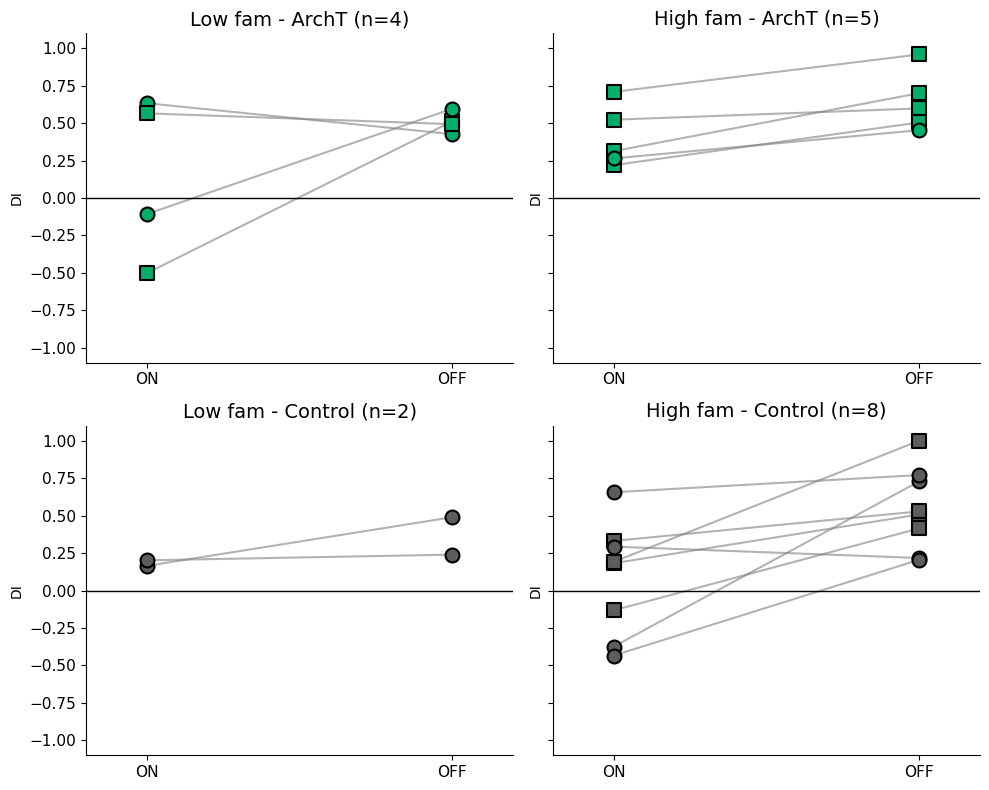

In [44]:
# ----------------------------
# 1. FILTER non-recognizers
# ----------------------------
df_pivot_clean = df_pivot[df_pivot["off"] > 0.2].copy()

print("Original N:", df_pivot.shape[0])
print("Filtered N:", df_pivot_clean.shape[0])

# ----------------------------
# 2. SUBSETS
# ----------------------------
lf_archt = df_pivot_clean[(df_pivot_clean.fam_level=="lf") & (df_pivot_clean.group=="ArchT")]
hf_archt = df_pivot_clean[(df_pivot_clean.fam_level=="cm") & (df_pivot_clean.group=="ArchT")]

lf_ctrl = df_pivot_clean[(df_pivot_clean.fam_level=="lf") & (df_pivot_clean.group=="control")]
hf_ctrl = df_pivot_clean[(df_pivot_clean.fam_level=="cm") & (df_pivot_clean.group=="control")]

# ----------------------------
# 3. PLOTTING FUNCTION
# ----------------------------
def plot_paired(ax, data, title, color):
    for _, row in data.iterrows():
        if pd.notna(row["on"]) and pd.notna(row["off"]):

            # 🔥 marker based on sex
            if row["sex"] == "f":
                marker = 'o'   # Female = circle
            elif row["sex"] == "m":
                marker = 's'   # Male = square
            else:
                marker = 'o'

            # connecting line
            ax.plot(
                ["ON", "OFF"],
                [row["on"], row["off"]],
                color='gray',
                alpha=0.6,
                linewidth=1.5
            )

            # points with sex-specific marker
            ax.scatter(
        ["ON", "OFF"],
        [row["on"], row["off"]],
        color=color,
        s=100,                 # slightly bigger
        marker=marker,
        edgecolor='black',     # 👈 outline
        linewidth=1.5,         # 👈 make it visible
        zorder=3               # 👈 keep points on top of lines
)

    # baseline
    ax.axhline(0, color='black', linewidth=1)

    # dynamic y limits
    if len(data) > 0:
        y_min = data[["on","off"]].min().min()
        y_max = data[["on","off"]].max().max()
        pad = 0.1
        ax.set_ylim(-1.1, 1.1)

    ax.set_xlim(-0.2, 1.2)

    # formatting
    ax.set_title(f"{title} (n={len(data)})", fontsize=14)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["ON","OFF"])
    ax.set_ylabel("DI")
    ax.tick_params(axis='both', labelsize=11)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ----------------------------
# 4. MAKE FIGURE
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(10,8), sharey=True)

archt_color = "#02AF6A"
control_color = "#5B5E5A"

plot_paired(axes[0,0], lf_archt, "Low fam - ArchT", archt_color)
plot_paired(axes[0,1], hf_archt, "High fam - ArchT", archt_color)
plot_paired(axes[1,0], lf_ctrl, "Low fam - Control", control_color)
plot_paired(axes[1,1], hf_ctrl, "High fam - Control", control_color)

plt.tight_layout()
plt.show()

Original N: 49
Filtered N: 19


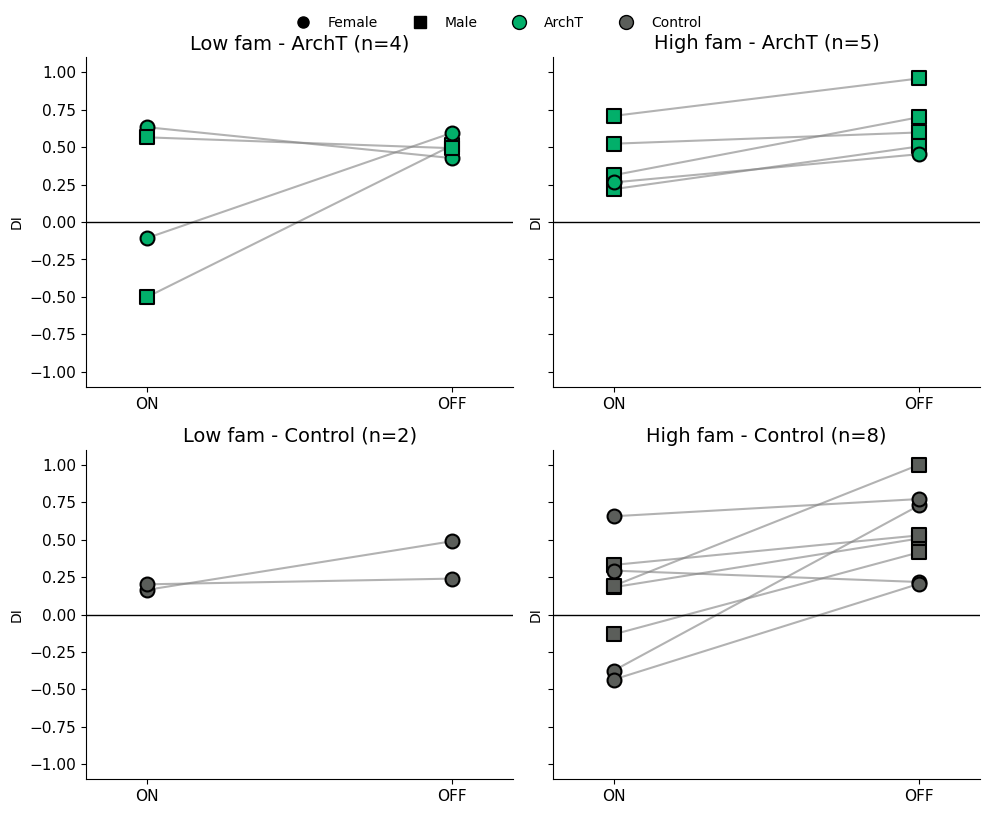

In [46]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----------------------------
# 1. FILTER non-recognizers
# ----------------------------
df_pivot_clean = df_pivot[df_pivot["off"] > 0.2].copy()

print("Original N:", df_pivot.shape[0])
print("Filtered N:", df_pivot_clean.shape[0])

# ----------------------------
# 2. SUBSETS
# ----------------------------
lf_archt = df_pivot_clean[(df_pivot_clean.fam_level=="lf") & (df_pivot_clean.group=="ArchT")]
hf_archt = df_pivot_clean[(df_pivot_clean.fam_level=="cm") & (df_pivot_clean.group=="ArchT")]

lf_ctrl = df_pivot_clean[(df_pivot_clean.fam_level=="lf") & (df_pivot_clean.group=="control")]
hf_ctrl = df_pivot_clean[(df_pivot_clean.fam_level=="cm") & (df_pivot_clean.group=="control")]

# ----------------------------
# 3. PLOTTING FUNCTION
# ----------------------------
def plot_paired(ax, data, title, color):
    for _, row in data.iterrows():
        if pd.notna(row["on"]) and pd.notna(row["off"]):

            # marker based on sex
            if row["sex"] == "f":
                marker = 'o'   # Female = circle
            elif row["sex"] == "m":
                marker = 's'   # Male = square
            else:
                marker = 'o'

            # connecting line
            ax.plot(
                ["ON", "OFF"],
                [row["on"], row["off"]],
                color='gray',
                alpha=0.6,
                linewidth=1.5
            )

            # points
            ax.scatter(
                ["ON", "OFF"],
                [row["on"], row["off"]],
                color=color,
                s=100,
                marker=marker,
                edgecolor='black',
                linewidth=1.5,
                zorder=3
            )

    # baseline
    ax.axhline(0, color='black', linewidth=1)

    ax.set_ylim(-1.1, 1.1)
    ax.set_xlim(-0.2, 1.2)

    ax.set_title(f"{title} (n={len(data)})", fontsize=14)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["ON","OFF"])
    ax.set_ylabel("DI")
    ax.tick_params(axis='both', labelsize=11)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ----------------------------
# 4. MAKE FIGURE
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(10,8), sharey=True)

archt_color = "#02AF6A"
control_color = "#5B5E5A"

plot_paired(axes[0,0], lf_archt, "Low fam - ArchT", archt_color)
plot_paired(axes[0,1], hf_archt, "High fam - ArchT", archt_color)
plot_paired(axes[1,0], lf_ctrl, "Low fam - Control", control_color)
plot_paired(axes[1,1], hf_ctrl, "High fam - Control", control_color)

# ----------------------------
# 5. ADD LEGEND (GLOBAL)
# ----------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Female',
           markerfacecolor='black', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='s', color='w', label='Male',
           markerfacecolor='black', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='ArchT',
           markerfacecolor=archt_color, markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Control',
           markerfacecolor=control_color, markeredgecolor='black', markersize=10)
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()